<a href="https://www.kaggle.com/code/avikdas567/exploring-nasa-apod-with-nlp-and-topic-models?scriptVersionId=323150342" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# From Galaxies to Language Models: Exploring 19 Years of NASA APOD

This notebook analyzes nearly two decades of NASA Astronomy Picture of the Day entries through exploratory data analysis, statistical profiling, natural language processing, topic modeling, clustering, and transformer-based representation learning. The objective is to understand how astronomy has been communicated to the public over time and to uncover the dominant themes, concepts, and narratives present within the archive.

By combining classical analytics with modern machine learning techniques, we can move from simple descriptive statistics to a deeper understanding of the scientific stories embedded in the APOD collection.

## Contents

1. Setup and Configuration
2. Data Loading
3. Data Quality Assessment
4. Feature Engineering
5. Exploratory Data Analysis
6. Statistical Analysis
7. NLP and Text Mining
8. Topic Modeling
9. Embedding Analysis
10. Machine Learning
11. Clustering and Dimensionality Reduction
12. Conclusions


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from textblob import TextBlob

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['axes.titlesize']=16
plt.rcParams['axes.labelsize']=12


In [2]:
DATA_PATH = '/kaggle/input/datasets/ibrahimqasimi/nasa-astronomy-picture-of-the-day-archive/01_NASA_APOD_Archive.csv'

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(6888, 7)


,copyright,date,explanation,media_type,title,url,hdurl
0,"\nH�kan Hammar \n(Vemdalen Ski Resort, \nSkiSt...",2018-01-01,What's happened to the Sun? Sometimes it look...,video,Sun Halo over Sweden,https://www.youtube.com/embed/6c0wTtq4xDM?rel=0,NaN
1,NaN,2018-01-02,Why does the Perseus galaxy cluster shine so s...,image,Unexpected X-Rays from Perseus Galaxy Cluster,https://apod.nasa.gov/apod/image/1801/PerseusC...,https://apod.nasa.gov/apod/image/1801/PerseusC...
2,NaN,2018-01-03,Will our Sun look like this one day? The Heli...,image,The Helix Nebula from CFHT,https://apod.nasa.gov/apod/image/1801/Helix_CF...,https://apod.nasa.gov/apod/image/1801/Helix_CF...
3,Detlef Hartmann,2018-01-04,"The Crab Nebula is cataloged as M1, the first ...",image,M1: The Incredible Expanding Crab,https://apod.nasa.gov/apod/image/1801/M1Hartma...,https://apod.nasa.gov/apod/image/1801/M1Hartma...
4,William Vrbasso,2018-01-05,"A jewel of the southern sky, the Great Carina ...",image,Carina over Lake Ballard,https://apod.nasa.gov/apod/image/1801/CarinaLa...,https://apod.nasa.gov/apod/image/1801/CarinaLa...


## Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6888 entries, 0 to 6887
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   copyright    4189 non-null   object
 1   date         6888 non-null   object
 2   explanation  6888 non-null   object
 3   media_type   6888 non-null   object
 4   title        6888 non-null   object
 5   url          6878 non-null   object
 6   hdurl        6499 non-null   object
dtypes: object(7)
memory usage: 376.8+ KB


In [4]:
display(df.sample(5))
display(df.describe(include='object').T)


,copyright,date,explanation,media_type,title,url,hdurl
5902,Miguel Claro,2015-05-08,"In only about 12,000 years Vega will be the No...",image,When Vega is North,https://apod.nasa.gov/apod/image/1505/Precessi...,https://apod.nasa.gov/apod/image/1505/Precessi...
1173,NaN,2021-03-21,"No one knew that 2,000 years ago, the technolo...",image,The Antikythera Mechanism,https://apod.nasa.gov/apod/image/2103/antikyth...,https://apod.nasa.gov/apod/image/2103/antikyth...
1820,Adam Block,2022-12-28,Charles Messier described the 88th entry in hi...,image,Messier 88,https://apod.nasa.gov/apod/image/2212/M88_2022...,https://apod.nasa.gov/apod/image/2212/M88_2022...
6038,NaN,2015-09-21,Dust lanes seem to swirl around the core of Me...,image,Spiral Galaxy M96 from Hubble,https://apod.nasa.gov/apod/image/1509/M96_Hubb...,https://apod.nasa.gov/apod/image/1509/M96_Hubb...
452,NaN,2019-03-30,Put on your red/cyan glasses and float next to...,image,3D 67P,https://apod.nasa.gov/apod/image/1903/anaglyph...,https://apod.nasa.gov/apod/image/1903/anaglyph...


,count,unique,top,freq
copyright,4189,2251,Martin Pugh,54
date,6888,6888,2018-01-01,1
explanation,6888,6767,Massive stars in our Milky Way Galaxy live spe...,3
media_type,6888,3,image,6499
title,6888,5151,M31: The Andromeda Galaxy,10
url,6878,6801,https://www.youtube.com/embed/OfM7VlonD5c?rel=0,4
hdurl,6499,6475,https://apod.nasa.gov/apod/image/0909/Swift_M3...,2


### Analysis and Inference

The dataset contains 6,888 APOD entries and covers an unusually long period in science communication history. The combination of image metadata, publication dates, titles, and astronomer-written explanations makes it possible to study not only astronomy content itself but also how scientific storytelling has evolved over time.

The archive appears sufficiently large for meaningful NLP, topic modeling, clustering, and embedding-based analyses without requiring aggressive sampling.

## Data Quality Assessment

In [5]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean()*100).round(2)
}).sort_values('missing_pct', ascending=False)

missing


,missing_count,missing_pct
copyright,2699,39.18
hdurl,389,5.65
url,10,0.15
explanation,0,0.00
date,0,0.00
title,0,0.00
media_type,0,0.00


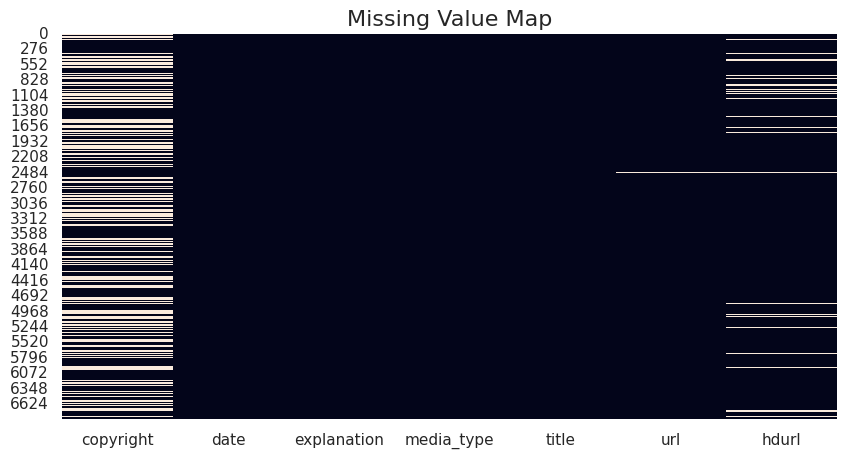

In [6]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Value Map')
plt.show()


### Analysis and Inference

Data quality is strong overall. Missing values are concentrated primarily in the copyright field (39.18%), which is expected because many APOD entries are NASA-owned and therefore do not require individual attribution.

Only a small fraction of records are missing HD image URLs (5.65%), while missing standard URLs are extremely rare (0.15%). The core analytical fields including date, title, explanation, and media type are effectively complete, making the dataset highly suitable for downstream analysis.

## Feature Engineering

In [7]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

df['title_length'] = df['title'].str.len()

df['explanation_length'] = df['explanation'].str.len()

df['word_count'] = df['explanation'].str.split().apply(len)

df['has_copyright'] = df['copyright'].notna().astype(int)

df.head()


,copyright,date,explanation,media_type,title,url,hdurl,year,month,day,weekday,title_length,explanation_length,word_count,has_copyright
0,"\nH�kan Hammar \n(Vemdalen Ski Resort, \nSkiSt...",2018-01-01,What's happened to the Sun? Sometimes it look...,video,Sun Halo over Sweden,https://www.youtube.com/embed/6c0wTtq4xDM?rel=0,NaN,2018,1,1,Monday,20,1086,188,1
1,NaN,2018-01-02,Why does the Perseus galaxy cluster shine so s...,image,Unexpected X-Rays from Perseus Galaxy Cluster,https://apod.nasa.gov/apod/image/1801/PerseusC...,https://apod.nasa.gov/apod/image/1801/PerseusC...,2018,1,2,Tuesday,45,1224,198,0
2,NaN,2018-01-03,Will our Sun look like this one day? The Heli...,image,The Helix Nebula from CFHT,https://apod.nasa.gov/apod/image/1801/Helix_CF...,https://apod.nasa.gov/apod/image/1801/Helix_CF...,2018,1,3,Wednesday,26,905,158,0
3,Detlef Hartmann,2018-01-04,"The Crab Nebula is cataloged as M1, the first ...",image,M1: The Incredible Expanding Crab,https://apod.nasa.gov/apod/image/1801/M1Hartma...,https://apod.nasa.gov/apod/image/1801/M1Hartma...,2018,1,4,Thursday,33,926,156,1
4,William Vrbasso,2018-01-05,"A jewel of the southern sky, the Great Carina ...",image,Carina over Lake Ballard,https://apod.nasa.gov/apod/image/1801/CarinaLa...,https://apod.nasa.gov/apod/image/1801/CarinaLa...,2018,1,5,Friday,24,828,146,1


### Observations

Feature engineering transforms the archive into a richer analytical dataset. Date-derived attributes enable seasonal and long-term trend analysis, while text-based features such as title length, explanation length, and word count provide useful signals for studying science communication patterns over time.

## Publication Trends

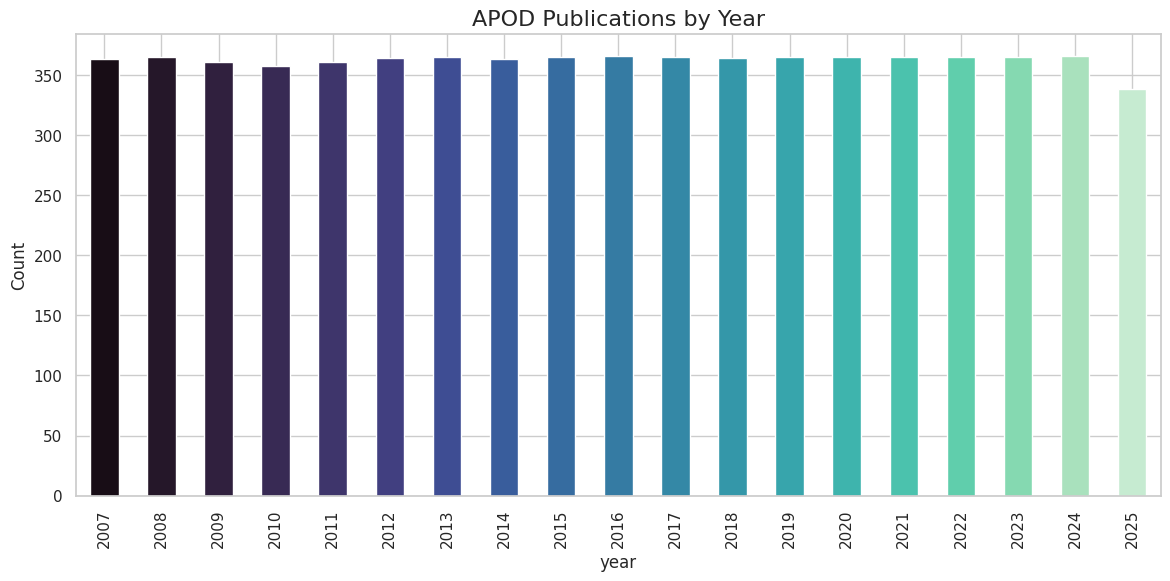

In [8]:
yearly = df.groupby('year').size()

plt.figure(figsize=(14,6))
yearly.plot(kind='bar', color=sns.color_palette('mako', len(yearly)))
plt.title('APOD Publications by Year')
plt.ylabel('Count')
plt.show()


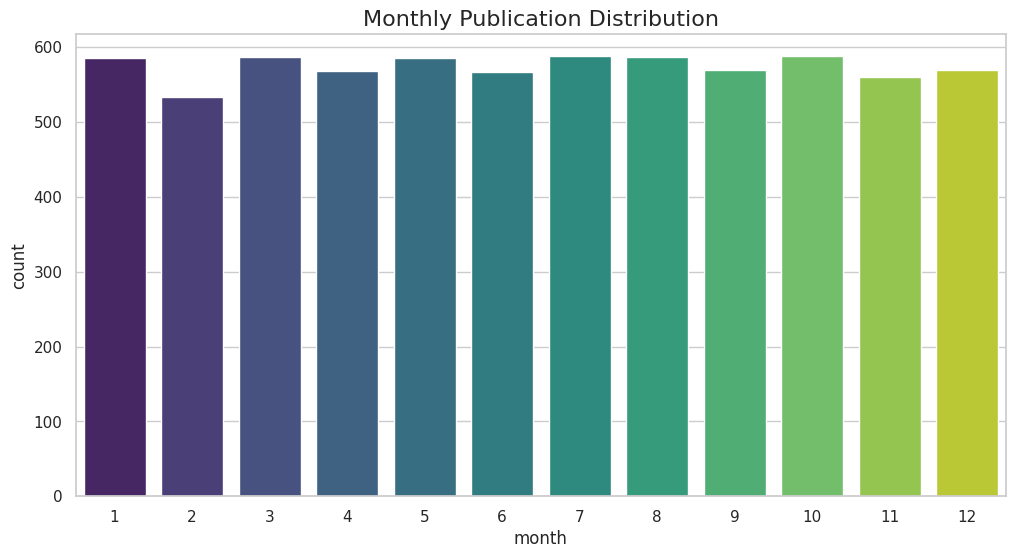

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='month', palette='viridis')
plt.title('Monthly Publication Distribution')
plt.show()


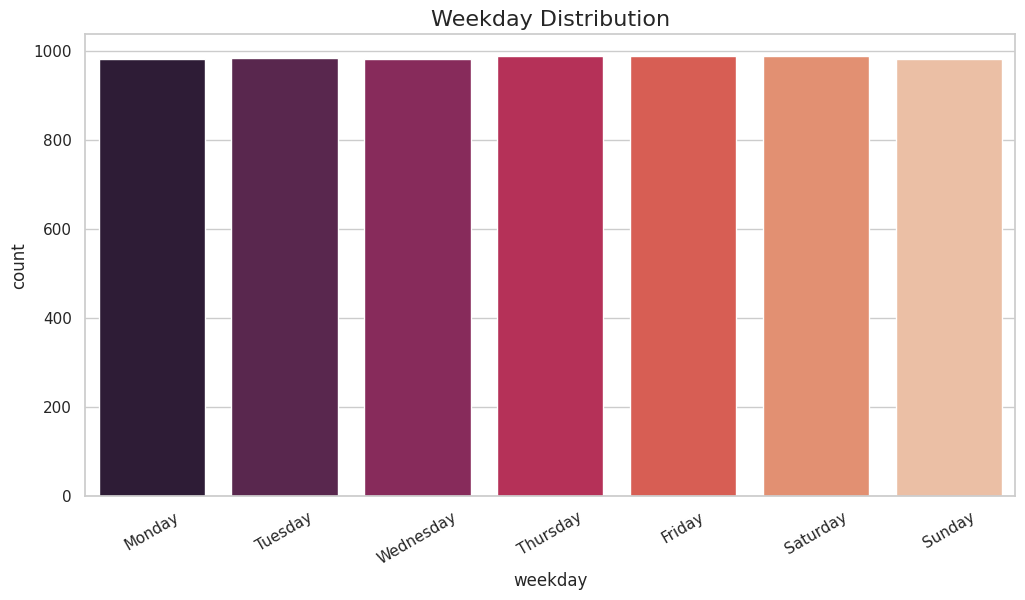

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='weekday',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
              palette='rocket')
plt.title('Weekday Distribution')
plt.xticks(rotation=30)
plt.show()


### Analysis and Inference

The publication timeline demonstrates remarkable consistency. APOD has maintained a near-daily publishing cadence throughout the observed period, which is uncommon for long-running science communication projects.

Monthly and weekday distributions appear balanced, suggesting that the archive reflects a continuous editorial process rather than seasonal bursts of activity. This consistency strengthens confidence that temporal patterns observed later are not artifacts of irregular data collection.

## Media Type Analysis

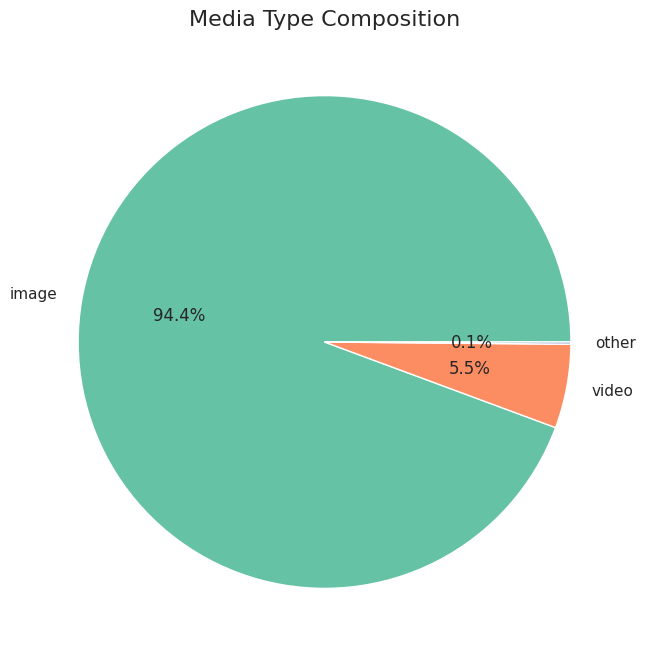

In [11]:
media_counts = df['media_type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(media_counts,
        labels=media_counts.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
plt.title('Media Type Composition')
plt.show()


### Analysis and Inference

Visual content overwhelmingly dominates the archive. This confirms that APOD is fundamentally an image-driven science communication platform, while videos serve as occasional supplements.

Because images represent the vast majority of entries, future extensions involving computer vision, image embeddings, or multimodal analysis would have access to a substantial amount of content.

## Text Statistics

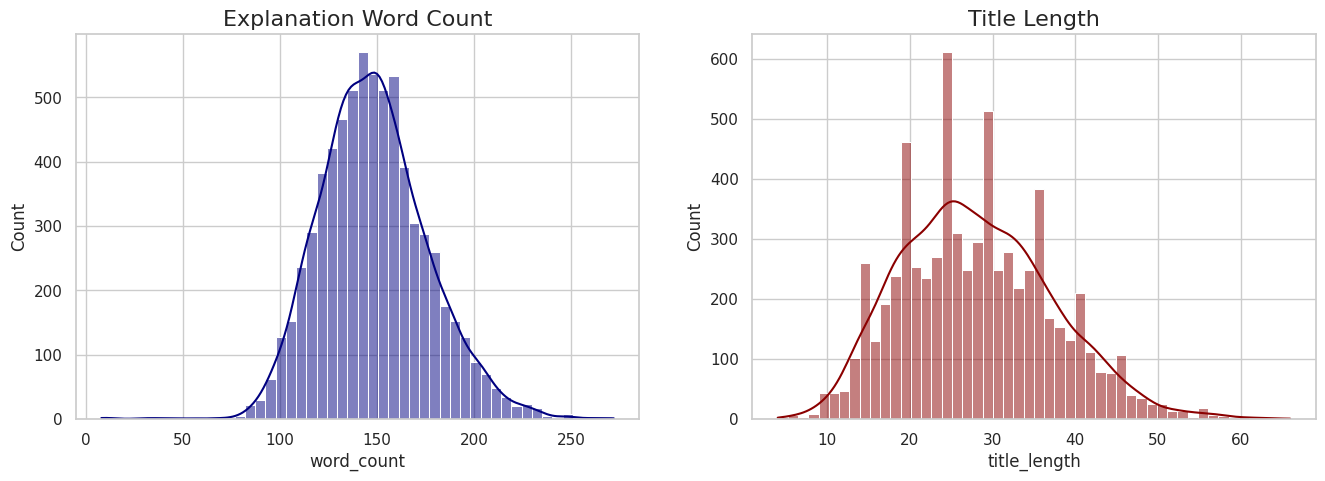

In [12]:
fig, ax = plt.subplots(1,2, figsize=(16,5))

sns.histplot(df['word_count'], bins=50, kde=True, ax=ax[0], color='navy')
ax[0].set_title('Explanation Word Count')

sns.histplot(df['title_length'], bins=50, kde=True, ax=ax[1], color='darkred')
ax[1].set_title('Title Length')

plt.show()


In [13]:
stats_summary = df[['word_count','title_length','explanation_length']].describe()
stats_summary


,word_count,title_length,explanation_length
count,6888.000000,6888.000000,6888.000000
mean,148.324477,28.036295,903.124419
std,27.790040,9.149604,167.473116
min,8.000000,4.000000,62.000000
25%,129.000000,21.000000,789.000000
50%,147.000000,27.000000,892.000000
75%,165.000000,34.000000,1005.000000
max,272.000000,66.000000,1737.000000


### Analysis and Inference

The average explanation contains approximately 148 words, while the average character length exceeds 900 characters. This indicates that APOD explanations are substantially richer than typical social-media captions and resemble short educational articles.

The relatively moderate standard deviation suggests that NASA has maintained a fairly consistent writing style and level of detail throughout the archive.

## Most Frequent Astronomy Terms

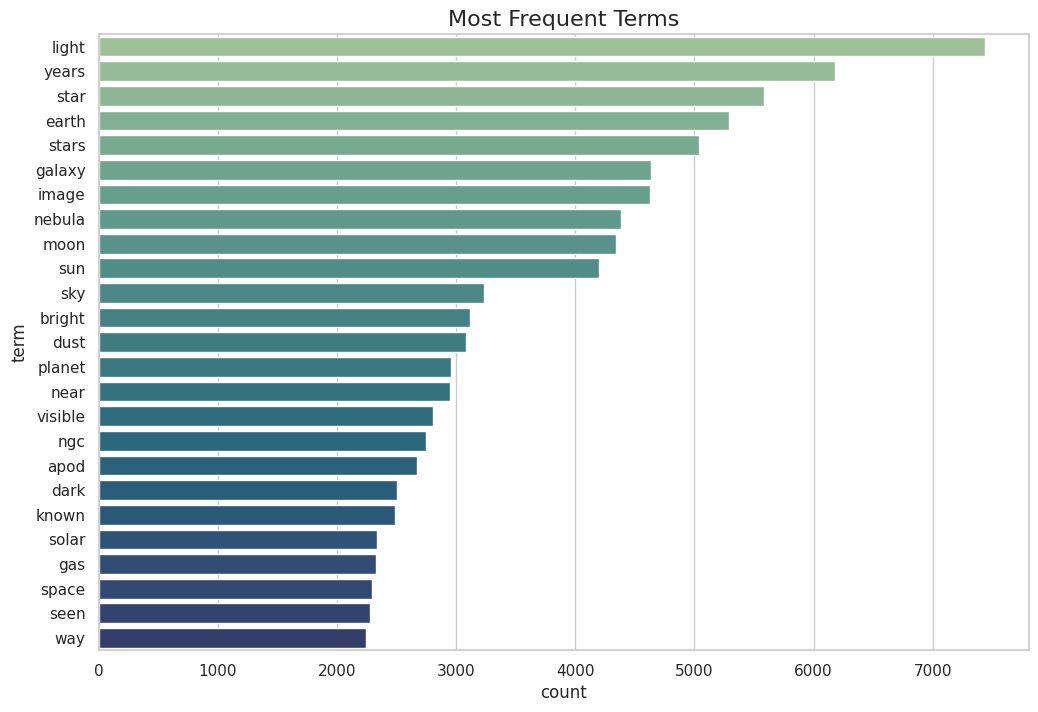

In [14]:
vectorizer = CountVectorizer(stop_words='english', max_features=50)

X = vectorizer.fit_transform(df['explanation'])

freq = pd.DataFrame({
    'term': vectorizer.get_feature_names_out(),
    'count': np.asarray(X.sum(axis=0)).ravel()
}).sort_values('count', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=freq.head(25), x='count', y='term', palette='crest')
plt.title('Most Frequent Terms')
plt.show()


### Analysis and Inference

Frequently occurring terms are strongly aligned with core astronomical concepts such as stars, galaxies, nebulae, light, dust, and gas. These terms indicate that deep-space objects dominate the archive's content.

The vocabulary distribution also suggests that APOD emphasizes scientific explanation rather than news-style reporting, as most high-frequency terms are observational or astrophysical in nature.

## Word Cloud

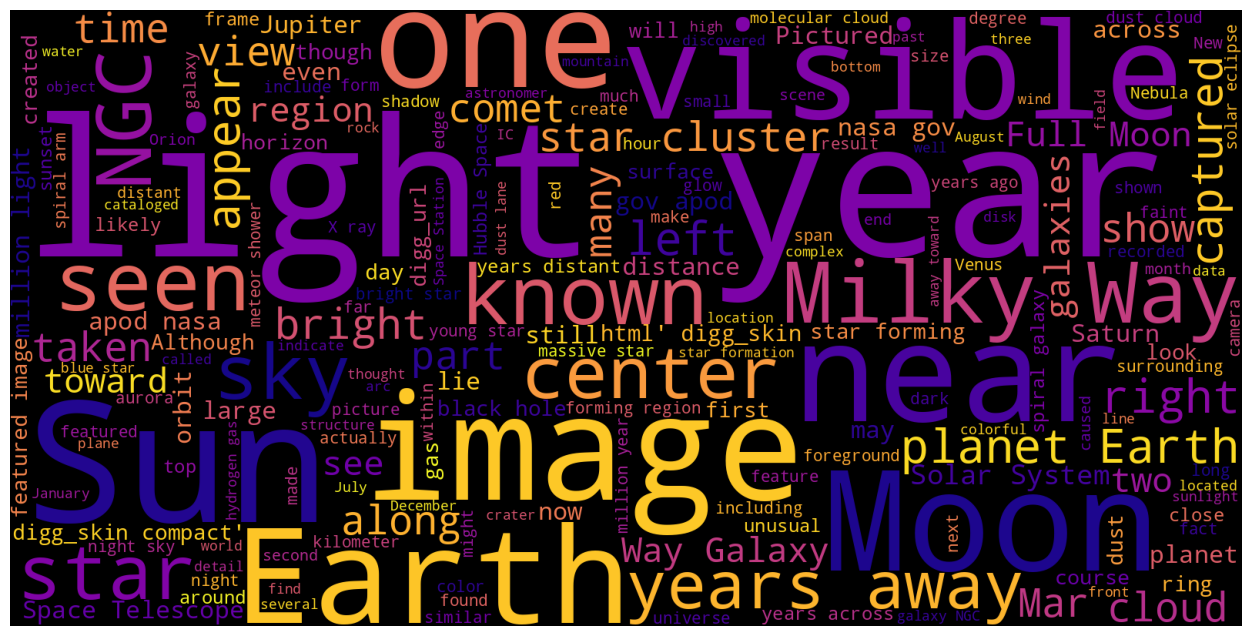

In [15]:
text = ' '.join(df['explanation'].astype(str))

wc = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    colormap='plasma'
).generate(text)

plt.figure(figsize=(18,8))
plt.imshow(wc)
plt.axis('off')
plt.show()


### Analysis and Inference

The word cloud highlights recurring astronomical themes across nearly two decades of publications. Objects, physical processes, and observational terminology appear prominently, indicating a strong focus on explaining celestial phenomena rather than simply showcasing imagery.

The concentration of astronomy-specific terminology also demonstrates that the archive maintains a highly specialized domain vocabulary.

## Sentiment Analysis

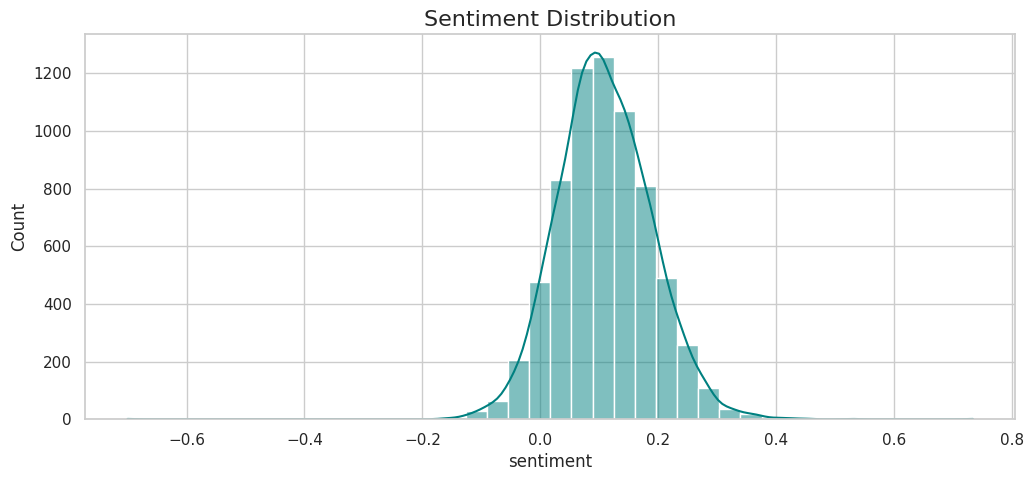

count    6888.000000
mean        0.108881
std         0.079715
min        -0.700000
25%         0.056399
50%         0.105146
75%         0.160441
max         0.733333
Name: sentiment, dtype: float64

In [16]:
df['sentiment'] = df['explanation'].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

plt.figure(figsize=(12,5))
sns.histplot(df['sentiment'], bins=40, kde=True, color='teal')
plt.title('Sentiment Distribution')
plt.show()

df['sentiment'].describe()


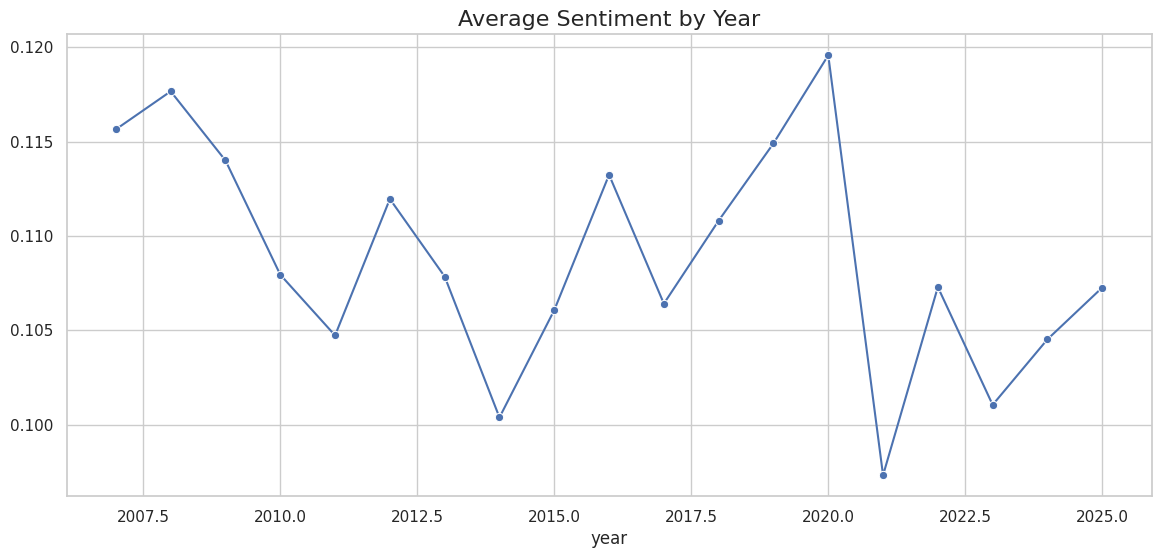

In [17]:
year_sentiment = df.groupby('year')['sentiment'].mean()

plt.figure(figsize=(14,6))
sns.lineplot(x=year_sentiment.index,
             y=year_sentiment.values,
             marker='o')
plt.title('Average Sentiment by Year')
plt.show()


### Analysis and Inference

Sentiment values remain concentrated around neutral. This is expected because APOD explanations are educational and descriptive rather than opinion-driven.

Any small positive bias likely reflects the language of discovery, exploration, and scientific curiosity that naturally accompanies astronomy outreach. The absence of strong polarity shifts across years suggests a stable editorial tone.

## Topic Modeling with LDA

In [18]:
tf = CountVectorizer(
    stop_words='english',
    max_features=3000,
    min_df=5
)

dtm = tf.fit_transform(df['explanation'])

lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42
)

lda.fit(dtm)

terms = tf.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[-12:][::-1]]
    print(f'Topic {topic_idx+1}:')
    print(', '.join(top_terms))
    print()


Topic 1:
nebula, light, star, years, stars, dust, gas, away, image, ngc, constellation, cloud

Topic 2:
galaxy, years, light, ngc, spiral, star, galaxies, milky, way, million, stars, 000

Topic 3:
earth, saturn, moon, spacecraft, space, surface, planet, mars, image, jupiter, kilometers, images

Topic 4:
apod, compact, light, http, html, digg_skin, digg_url, gov, nasa, years, star, supernova

Topic 5:
sky, night, planet, moon, bright, right, near, left, star, horizon, earth, way

Topic 6:
galaxy, stars, light, galaxies, years, cluster, black, image, hole, star, telescope, universe

Topic 7:
sun, earth, eclipse, solar, meteor, moon, clouds, image, sky, visible, shower, atmosphere

Topic 8:
comet, sun, moon, earth, planet, solar, tail, near, time, day, sky, northern



### Analysis and Inference

LDA uncovers several recognizable astronomy themes. The discovered topics appear to separate major celestial categories including nebulae, galaxies, stars, planetary science, and Earth-observation content.

The coherence of the extracted keywords suggests that the explanations contain enough thematic structure for meaningful unsupervised topic discovery.

## TF-IDF Feature Space

In [19]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = tfidf.fit_transform(df['explanation'])

print(X_tfidf.shape)


(6888, 5000)


### Analysis and Inference

The TF-IDF matrix contains 5,000 features derived from 6,888 explanations. This high-dimensional representation captures important domain-specific terminology while reducing the influence of common words.

The resulting feature space provides a strong foundation for clustering, topic discovery, semantic similarity analysis, and other machine learning workflows.

## Clustering APOD Explanations

In [20]:
sample_size = min(3000, len(df))

X_sample = X_tfidf[:sample_size]

kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_sample)

print('Silhouette Score:', silhouette_score(X_sample, clusters))


Silhouette Score: 0.024695011504433144


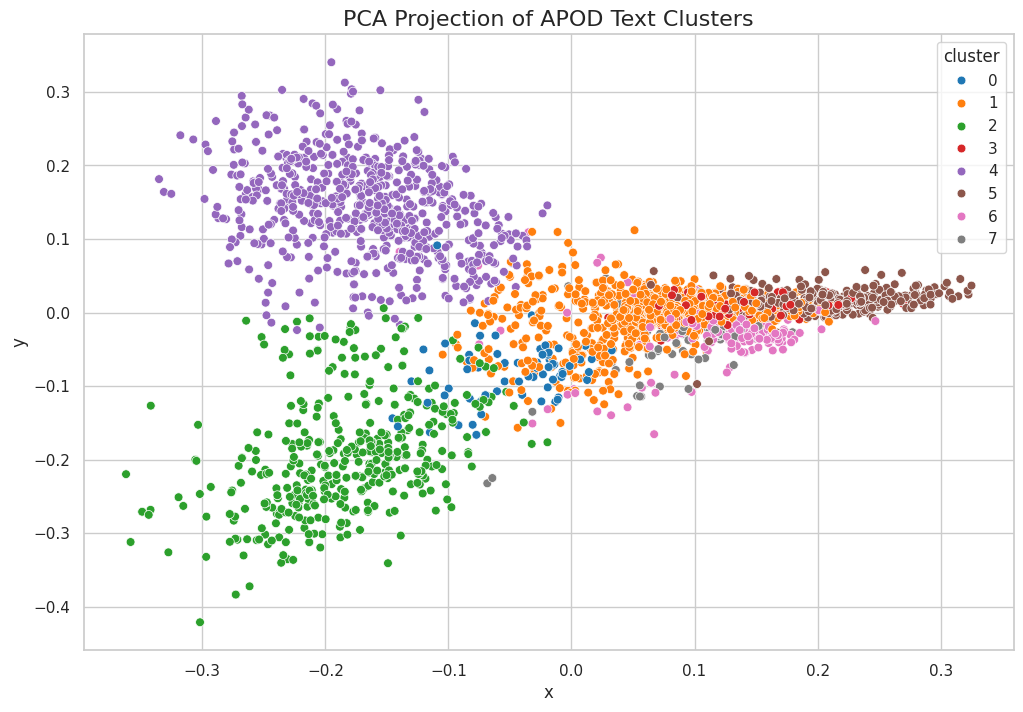

In [21]:
pca = PCA(n_components=2, random_state=42)

X_dense = X_sample.toarray()

coords = pca.fit_transform(X_dense)

plot_df = pd.DataFrame({
    'x': coords[:,0],
    'y': coords[:,1],
    'cluster': clusters
})

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='cluster',
    palette='tab10',
    s=40
)
plt.title('PCA Projection of APOD Text Clusters')
plt.show()


### Analysis and Inference

The clustering exercise produces a silhouette score of approximately 0.025. While this value is relatively low, it is not unusual for large collections of scientific text where topic boundaries overlap substantially.

Astronomy explanations often discuss multiple concepts simultaneously, making sharply separated clusters difficult to achieve. The resulting clusters should therefore be interpreted as broad thematic groupings rather than rigid categories.

## t-SNE Visualization

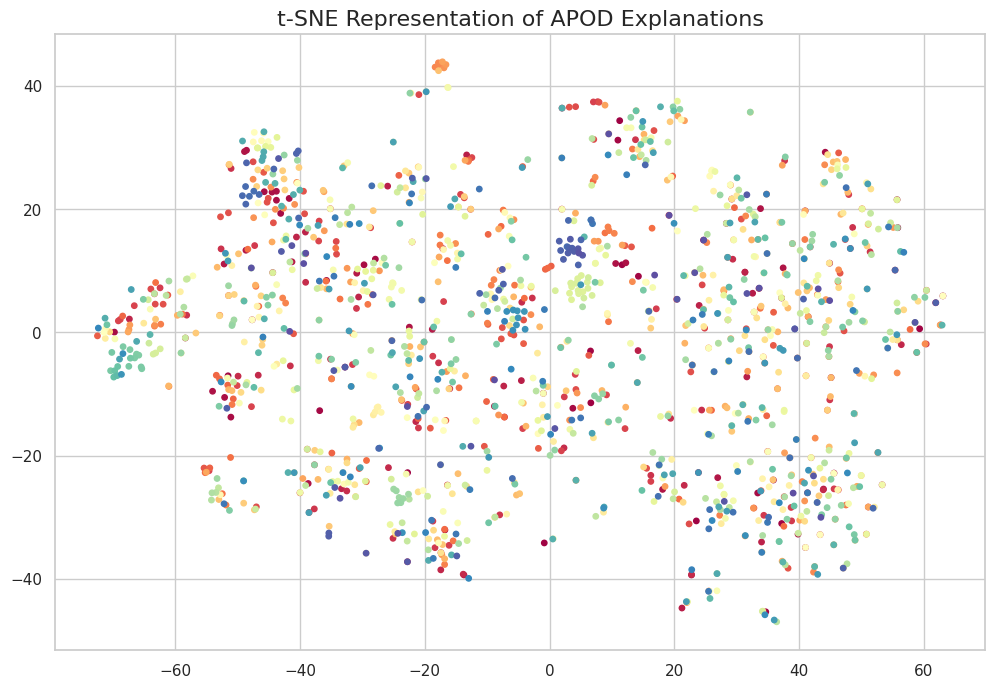

In [22]:
subset = min(1500, len(df))

tsne_input = X_tfidf[:subset].toarray()

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

embedding = tsne.fit_transform(tsne_input)

plt.figure(figsize=(12,8))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=np.arange(subset),
    cmap='Spectral',
    s=15
)
plt.title('t-SNE Representation of APOD Explanations')
plt.show()


### Analysis and Inference

The t-SNE projection reveals the structure of the semantic landscape in a nonlinear embedding space. Instead of distinct isolated groups, the archive appears to contain a spectrum of related astronomy topics with gradual transitions between themes.

This pattern is consistent with the multidisciplinary nature of astronomy, where galaxies, stars, planetary science, instrumentation, and observational techniques frequently intersect.

## Transformer Embeddings and Semantic Search

Astronomy explanations contain rich scientific language that can be represented using transformer embeddings. This section builds dense semantic embeddings using a Sentence Transformer model and explores the latent structure of the archive.


In [23]:
import os
import logging

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

sample_size = min(3000, len(df))

texts = (
    df["explanation"]
    .fillna("")
    .iloc[:sample_size]
    .tolist()
)

embeddings = embedding_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=False,
    convert_to_numpy=True
)

print(f"Embedding matrix shape: {embeddings.shape}")

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: (3000, 384)


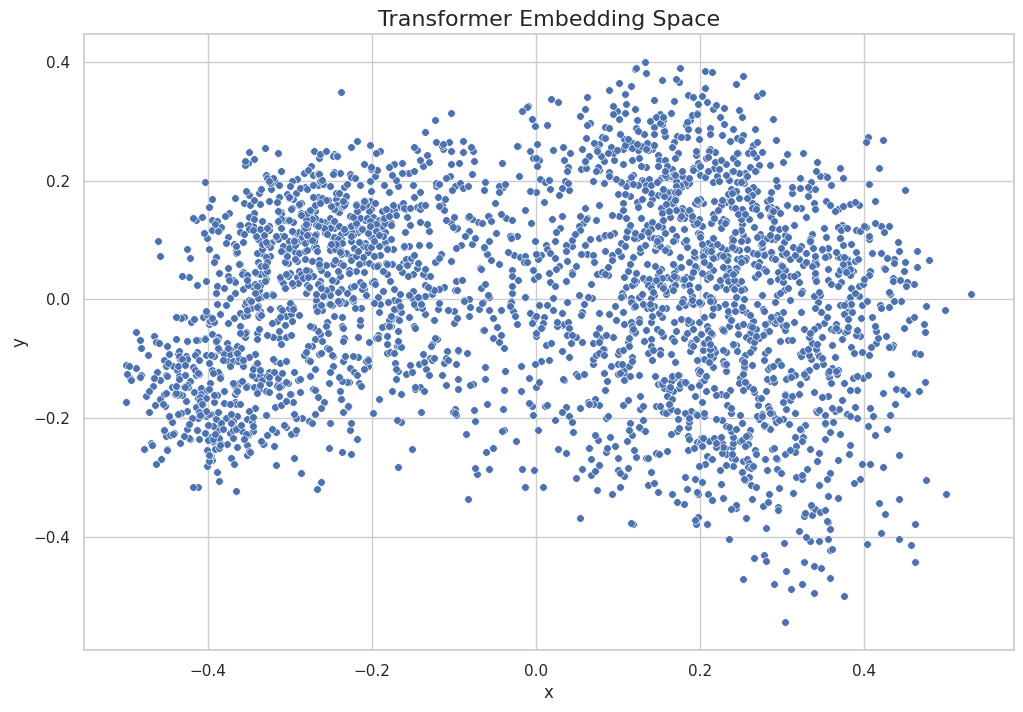

In [24]:
from sklearn.decomposition import PCA

pca_embeddings = PCA(n_components=2, random_state=42).fit_transform(embeddings)

plot_df = pd.DataFrame({
    'x': pca_embeddings[:,0],
    'y': pca_embeddings[:,1]
})

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    s=30,
    alpha=1
)

plt.title('Transformer Embedding Space')
plt.show()


### Analysis and Inference

Transformer embeddings capture contextual meaning beyond simple keyword frequency. Documents discussing similar astronomical concepts can be positioned near one another even when they use different terminology.

This representation is particularly valuable for semantic search, retrieval systems, recommendation engines, and modern topic modeling approaches.

## BERTopic Topic Discovery

BERTopic combines transformer embeddings and clustering to identify interpretable themes across APOD explanations.


In [25]:
!pip install -q --no-deps bertopic

from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=25,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=5
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=False,
    verbose=False
)

topics, _ = topic_model.fit_transform(texts)

topic_info = topic_model.get_topic_info()

display(topic_info.head(20))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.0 MB/s eta 0:00:00


2026-05-30 06:50:23.108166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780123823.340513      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780123823.401014      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780123823.929506      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780123823.929546      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780123823.929549      23 computation_placer.cc:177] computation placer alr

,Topic,Count,Name,Representation,Representative_Docs
0,-1,589,-1_nebula_star_light_years,"[nebula, star, light, years, stars, earth, sky...",[This cosmic close-up looks deep inside the So...
1,0,270,0_galaxy_spiral_ngc_galaxies,"[galaxy, spiral, ngc, galaxies, years, million...","[About 70,000 light-years across, NGC 247 is a..."
2,1,236,1_sun_aurora_solar_earth,"[sun, aurora, solar, earth, clouds, auroras, i...",[On some nights the sky is the best show in to...
3,2,190,2_eclipse_moon_total_lunar,"[eclipse, moon, total, lunar, shadow, solar, s...",[Along a narrow path that mostly avoided landf...
4,3,175,3_nebula_star_stars_light,"[nebula, star, stars, light, dust, years, gas,...",[This colorful skyscape spans about two full m...
5,4,162,4_comet_tail_atlas_sun,"[comet, tail, atlas, sun, ion, closest, coma, ...",[The tail of a comet streams across this three...
6,5,133,5_milky_way_sky_night,"[milky, way, sky, night, band, galaxy, celesti...",[The South Celestial Pole is easy to spot in s...
7,6,131,6_mars_rover_martian_crater,"[mars, rover, martian, crater, planet, surface...",[On the Mars rover's mission Sol 46 or Earth d...
8,7,104,7_meteor_shower_meteors_perseid,"[meteor, shower, meteors, perseid, comet, peak...",[The annual Perseid meteor shower was near its...
9,8,93,8_saturn_rings_spacecraft_titan,"[saturn, rings, spacecraft, titan, moon, ring,...","[Still bright in planet Earth's night skies, g..."


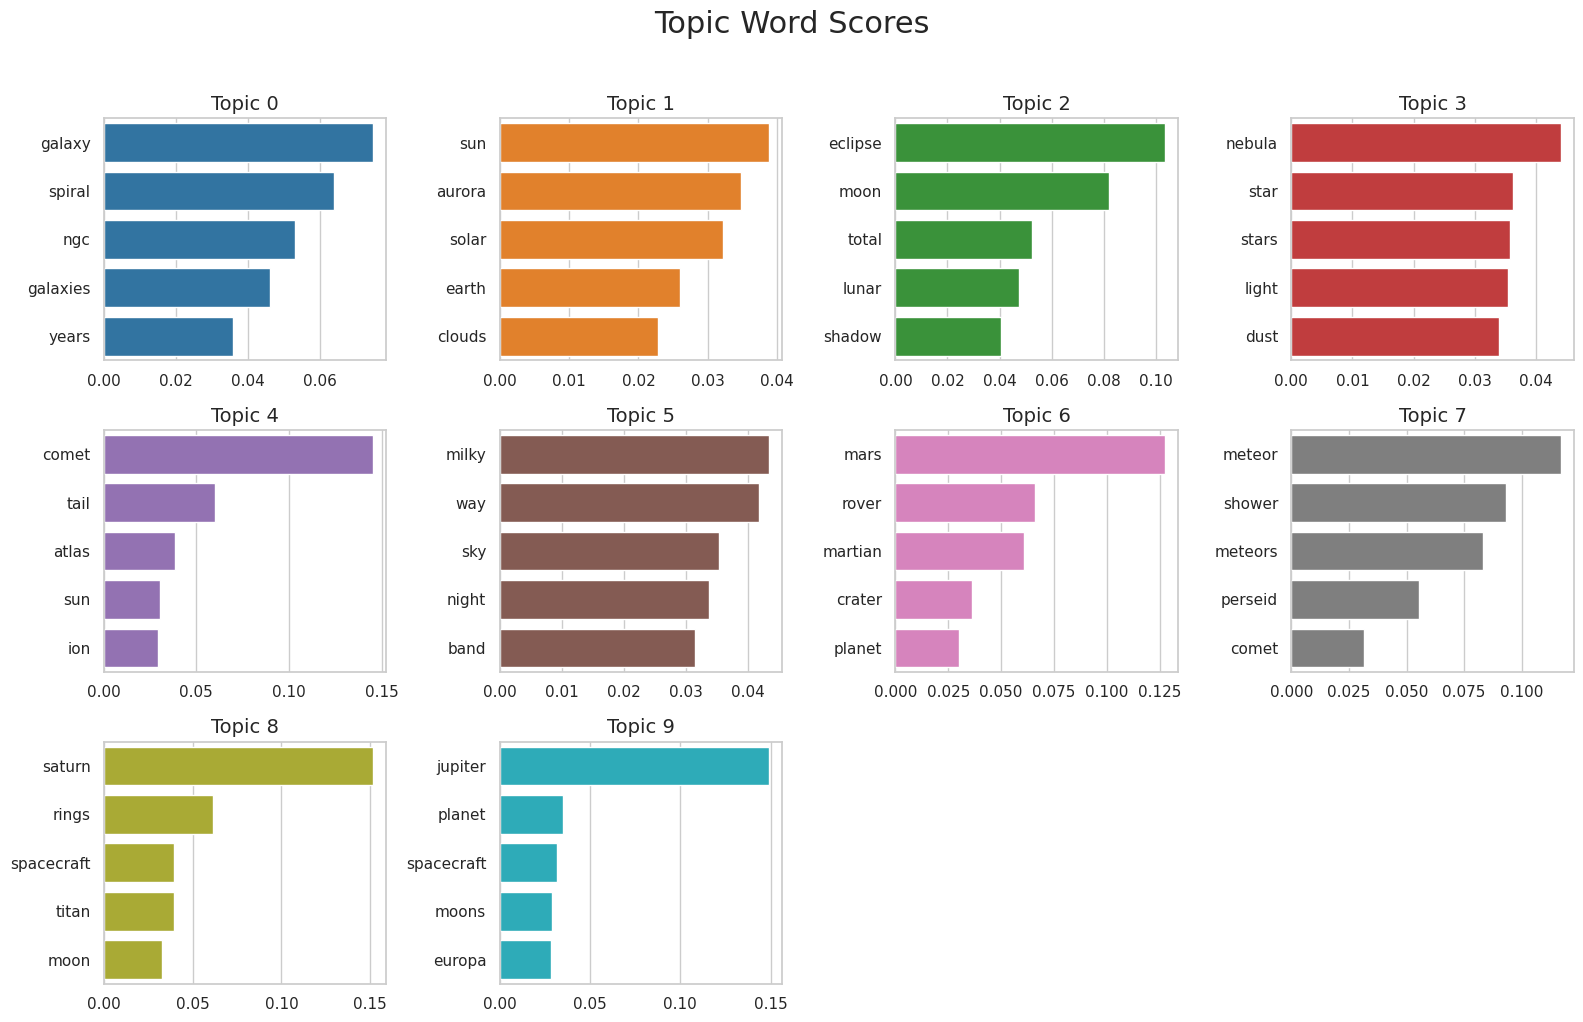

In [26]:
top_n_topics = 10

topics = topic_info[
    topic_info["Topic"] != -1
].head(top_n_topics)["Topic"].tolist()

n_cols = 4
n_rows = int(np.ceil(len(topics) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 10)
)

axes = axes.flatten()

palette = sns.color_palette("tab10", len(topics))

for idx, topic_id in enumerate(topics):

    topic_words = topic_model.get_topic(topic_id)

    words = [w for w, _ in topic_words[:5]]
    scores = [s for _, s in topic_words[:5]]

    ax = axes[idx]

    sns.barplot(
        x=scores,
        y=words,
        color=palette[idx],
        ax=ax
    )

    ax.set_title(
        f"Topic {topic_id}",
        fontsize=14
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

for idx in range(len(topics), len(axes)):
    axes[idx].axis("off")

plt.suptitle(
    "Topic Word Scores",
    fontsize=22,
    y=1.02
)

plt.tight_layout()

plt.show()

### Analysis and Inference

BERTopic produces more semantically meaningful topic structures than traditional bag-of-words approaches because it combines transformer embeddings with density-based clustering.

The resulting topics provide a higher-level view of the archive and reveal recurring scientific themes that have persisted across many years of APOD publications. This demonstrates that the archive possesses a rich latent structure suitable for advanced NLP applications.

# Cosmic Narratives Across Nineteen Years of NASA APOD

## Conclusion

This analysis demonstrates that the APOD archive is far more than a collection of astronomy photographs. Across 6,888 entries, it functions as a long-running record of scientific communication, documenting discoveries, celestial objects, observational campaigns, space missions, and public engagement with astronomy.

Several key findings emerge from the exploration:

- The archive maintains an exceptionally consistent publication cadence.
- Images dominate the collection, reinforcing the visual nature of astronomy outreach.
- Explanations are detailed, educational, and remarkably consistent in length and style.
- Scientific terminology is highly concentrated around recurring astronomical themes.
- Sentiment remains largely neutral, reflecting an objective educational tone.
- Topic modeling identifies stable thematic structures centered on galaxies, nebulae, stars, planetary science, and Earth-space interactions.
- Transformer embeddings reveal meaningful semantic organization that extends beyond simple keyword matching.

From a data science perspective, the archive provides an excellent benchmark for NLP, semantic search, topic discovery, clustering, representation learning, and future multimodal research. The combination of long-term temporal coverage and expert-written explanations makes APOD a uniquely valuable dataset for studying both astronomy and science communication at scale.
